In [1]:
import pandas as pd

In [59]:
# Работа с датой
# to_datetime
# set_index, DatetimeIndex
# Срезы loc
# Извлечение компонентов даты
# plot
# resample
# rolling
# shift, diff

# Задача:
# Скачать датасет с датой
# Создать DatetimeIndex
# Показть работу среза через loc
# Сделать график сравнение с обычными данными и resample, rolling

In [23]:
df = pd.read_csv('../data/raw/boston_weather_data.csv')

In [24]:
df

,time,tavg,tmin,tmax,prcp,wdir,wspd,pres
0,2013-03-01,3.2,1.1,5.0,0.0,342.0,15.1,1002.7
1,2013-03-02,3.1,1.1,5.6,0.0,307.0,14.4,1004.2
2,2013-03-03,2.6,0.6,6.1,0.0,NaN,14.4,1002.6
3,2013-03-04,1.8,-0.6,5.0,0.0,303.0,28.1,1003.0
4,2013-03-05,2.9,0.0,6.1,0.0,NaN,16.6,1013.5
...,...,...,...,...,...,...,...,...
3648,2023-02-25,-7.9,-10.6,-6.7,0.3,313.0,11.9,1029.5
3649,2023-02-26,-4.2,-7.8,3.9,0.0,268.0,11.9,1012.6
3650,2023-02-27,-1.7,-2.8,-0.6,0.0,46.0,18.7,1014.9
3651,2023-02-28,0.6,-1.7,2.2,7.1,86.0,23.8,1010.7


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3653 entries, 0 to 3652
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    3653 non-null   object 
 1   tavg    3652 non-null   float64
 2   tmin    3653 non-null   float64
 3   tmax    3653 non-null   float64
 4   prcp    3653 non-null   float64
 5   wdir    3066 non-null   float64
 6   wspd    3653 non-null   float64
 7   pres    3492 non-null   float64
dtypes: float64(7), object(1)
memory usage: 228.4+ KB


In [26]:
df['time'] = pd.to_datetime(df['time'])

In [27]:
pd.to_datetime('01.01.2025', format = '%d.%m.%Y')

Timestamp('2025-01-01 00:00:00')

In [28]:
df['time'].value_counts()

time
2023-03-01    1
2013-03-01    1
2013-03-02    1
2013-03-03    1
2013-03-04    1
             ..
2013-03-10    1
2013-03-09    1
2013-03-08    1
2013-03-07    1
2013-03-06    1
Name: count, Length: 3653, dtype: int64

In [34]:
df = df.set_index('time')

In [36]:
df

,tavg,tmin,tmax,prcp,wdir,wspd,pres
time,,,,,,,
2013-03-01,3.2,1.1,5.0,0.0,342.0,15.1,1002.7
2013-03-02,3.1,1.1,5.6,0.0,307.0,14.4,1004.2
2013-03-03,2.6,0.6,6.1,0.0,NaN,14.4,1002.6
2013-03-04,1.8,-0.6,5.0,0.0,303.0,28.1,1003.0
2013-03-05,2.9,0.0,6.1,0.0,NaN,16.6,1013.5
...,...,...,...,...,...,...,...
2023-02-25,-7.9,-10.6,-6.7,0.3,313.0,11.9,1029.5
2023-02-26,-4.2,-7.8,3.9,0.0,268.0,11.9,1012.6
2023-02-27,-1.7,-2.8,-0.6,0.0,46.0,18.7,1014.9


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3653 entries, 2013-03-01 to 2023-03-01
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tavg    3652 non-null   float64
 1   tmin    3653 non-null   float64
 2   tmax    3653 non-null   float64
 3   prcp    3653 non-null   float64
 4   wdir    3066 non-null   float64
 5   wspd    3653 non-null   float64
 6   pres    3492 non-null   float64
dtypes: float64(7)
memory usage: 228.3 KB


In [39]:
df.index

DatetimeIndex(['2013-03-01', '2013-03-02', '2013-03-03', '2013-03-04',
               '2013-03-05', '2013-03-06', '2013-03-07', '2013-03-08',
               '2013-03-09', '2013-03-10',
               ...
               '2023-02-20', '2023-02-21', '2023-02-22', '2023-02-23',
               '2023-02-24', '2023-02-25', '2023-02-26', '2023-02-27',
               '2023-02-28', '2023-03-01'],
              dtype='datetime64[ns]', name='time', length=3653, freq=None)

In [40]:
df[(df.index >= '2020-01-01') & (df.index < '2021-01-01')]

,tavg,tmin,tmax,prcp,wdir,wspd,pres
time,,,,,,,
2020-01-01,4.1,2.2,6.1,0.0,268.0,24.8,1003.0
2020-01-02,4.2,1.1,9.4,0.0,231.0,20.2,1010.7
2020-01-03,8.2,6.7,11.1,0.0,231.0,11.5,1008.2
2020-01-04,8.1,4.4,8.9,3.3,14.0,8.6,1004.0
2020-01-05,3.9,0.0,5.0,2.8,308.0,26.6,1004.1
...,...,...,...,...,...,...,...
2020-12-27,-0.7,-3.8,3.3,0.0,232.0,14.4,1023.2
2020-12-28,2.7,-2.1,9.4,0.0,189.0,15.1,1021.8
2020-12-29,2.7,-4.3,5.6,0.0,295.0,24.8,1024.5


In [41]:
df.loc['2020']

,tavg,tmin,tmax,prcp,wdir,wspd,pres
time,,,,,,,
2020-01-01,4.1,2.2,6.1,0.0,268.0,24.8,1003.0
2020-01-02,4.2,1.1,9.4,0.0,231.0,20.2,1010.7
2020-01-03,8.2,6.7,11.1,0.0,231.0,11.5,1008.2
2020-01-04,8.1,4.4,8.9,3.3,14.0,8.6,1004.0
2020-01-05,3.9,0.0,5.0,2.8,308.0,26.6,1004.1
...,...,...,...,...,...,...,...
2020-12-27,-0.7,-3.8,3.3,0.0,232.0,14.4,1023.2
2020-12-28,2.7,-2.1,9.4,0.0,189.0,15.1,1021.8
2020-12-29,2.7,-4.3,5.6,0.0,295.0,24.8,1024.5


In [42]:
df.loc['2020-01']

,tavg,tmin,tmax,prcp,wdir,wspd,pres
time,,,,,,,
2020-01-01,4.1,2.2,6.1,0.0,268.0,24.8,1003.0
2020-01-02,4.2,1.1,9.4,0.0,231.0,20.2,1010.7
2020-01-03,8.2,6.7,11.1,0.0,231.0,11.5,1008.2
2020-01-04,8.1,4.4,8.9,3.3,14.0,8.6,1004.0
2020-01-05,3.9,0.0,5.0,2.8,308.0,26.6,1004.1
2020-01-06,0.4,-2.7,5.0,0.0,242.0,10.8,1013.2
2020-01-07,3.2,0.6,5.6,0.0,214.0,14.8,1015.3
2020-01-08,3.4,-1.6,7.2,0.5,282.0,22.7,1010.9
2020-01-09,-1.6,-5.5,0.6,0.0,304.0,21.2,1035.2


In [44]:
df.loc[['2020-01-25']]

,tavg,tmin,tmax,prcp,wdir,wspd,pres
time,,,,,,,
2020-01-25,5.7,4.4,10.0,17.8,83.0,22.7,1020.4


In [45]:
df.loc['2019-03':'2020-02']

,tavg,tmin,tmax,prcp,wdir,wspd,pres
time,,,,,,,
2019-03-01,-1.4,-4.9,3.3,0.0,194.0,10.8,1027.1
2019-03-02,0.6,0.0,1.1,4.6,12.0,16.2,1018.1
2019-03-03,1.8,0.0,5.0,2.3,185.0,13.7,1017.8
2019-03-04,2.1,-3.8,4.4,24.6,324.0,21.2,1006.6
2019-03-05,-3.2,-7.1,-0.5,0.0,257.0,16.9,1014.8
...,...,...,...,...,...,...,...
2020-02-25,8.6,6.1,11.7,6.6,101.0,8.6,1012.8
2020-02-26,7.6,6.7,8.9,3.8,41.0,15.1,1014.4
2020-02-27,7.2,0.6,12.8,19.0,245.0,36.4,997.4


In [52]:
df['year'] = df.index.year
df['month'] = df.index.month
df['quarter'] = df.index.quarter
df['weekday'] = df.index.weekday
df['day_name'] = df.index.day_name()

In [62]:
df.groupby(by=['month'])['tavg'].mean()

month
1     -0.215161
2      0.448227
3      3.335484
4      8.982000
5     14.840323
6     20.172333
7     23.820645
8     23.317742
9     19.435667
10    13.632581
11     7.341667
12     2.798065
Name: tavg, dtype: float64

<Axes: xlabel='time'>

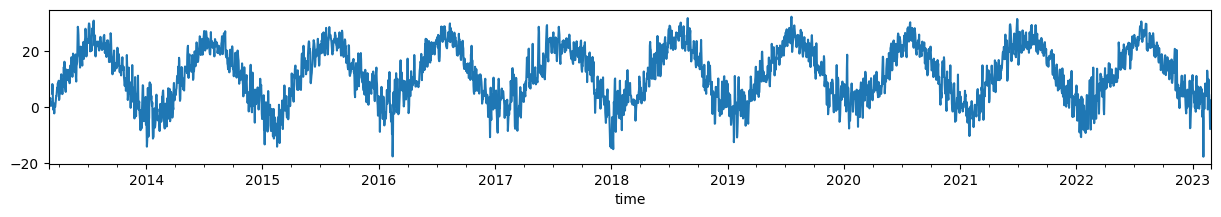

In [55]:
df['tavg'].plot(figsize=(15,2))

<Axes: xlabel='time'>

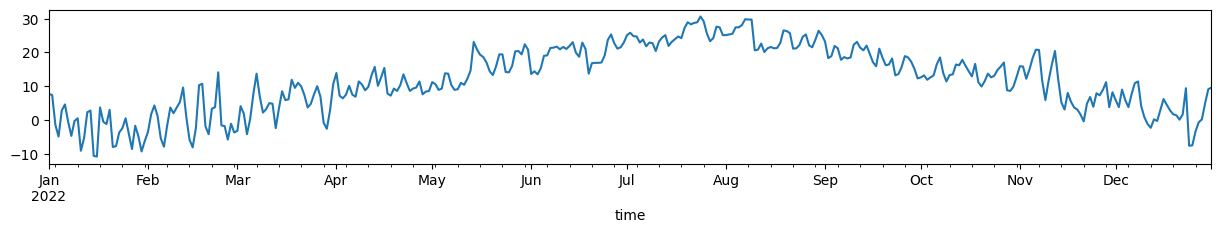

In [58]:
df['tavg'].loc['2022'].plot(figsize=(15,2))

In [77]:
avg_temp_year = df.loc['2014':'2022'].resample('YS')['tavg'].mean()

<Axes: xlabel='time'>

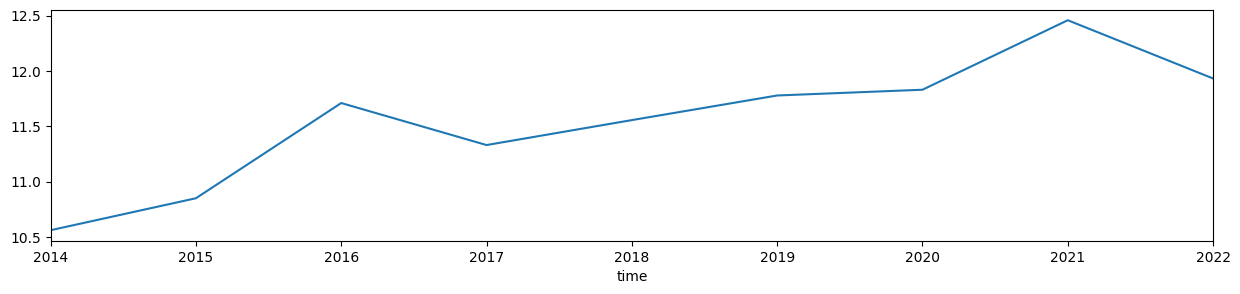

In [80]:
avg_temp_year.plot(figsize=(15,3))

In [95]:
df['tavg_window_30'] = df['tavg'].rolling(window=30).mean()

<Axes: xlabel='time'>

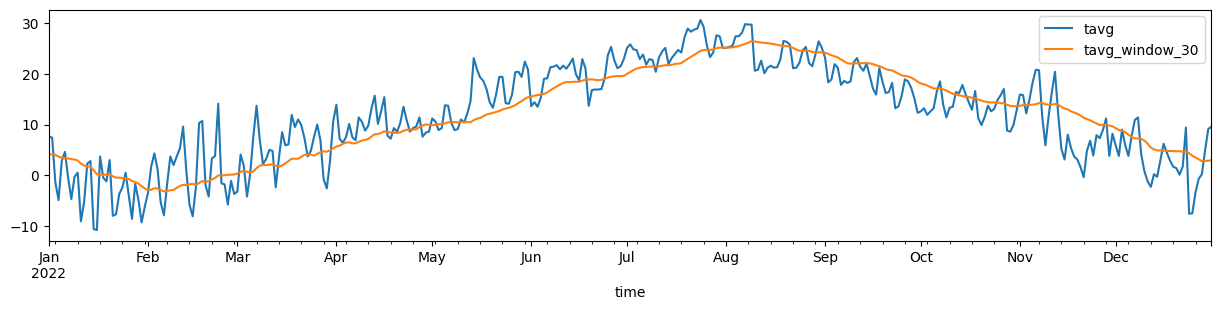

In [96]:
df[['tavg', 'tavg_window_30']].loc['2022'].plot(figsize=(15,3))

In [100]:
df['tavg_diff'] = df['tavg'].diff()

<Axes: xlabel='time'>

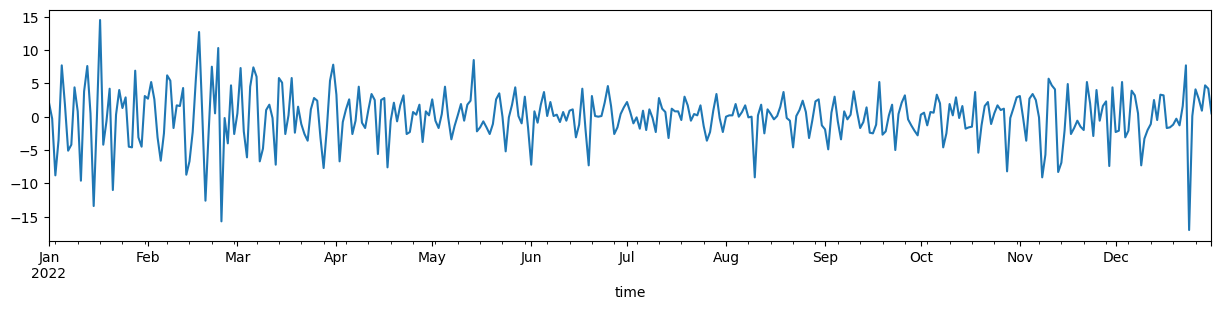

In [103]:
df['tavg_diff'].loc['2022'].plot(figsize=(15,3))

In [106]:
df['tavg_prev_7'] = df['tavg'].shift(7)

In [110]:
df[['tavg', 'tavg_prev_7']].loc['2020-01']

,tavg,tavg_prev_7
time,,
2020-01-01,4.1,2.6
2020-01-02,4.2,2.6
2020-01-03,8.2,4.9
2020-01-04,8.1,9.1
2020-01-05,3.9,4.2
2020-01-06,0.4,3.6
2020-01-07,3.2,4.6
2020-01-08,3.4,4.1
2020-01-09,-1.6,4.2


<Axes: xlabel='time'>

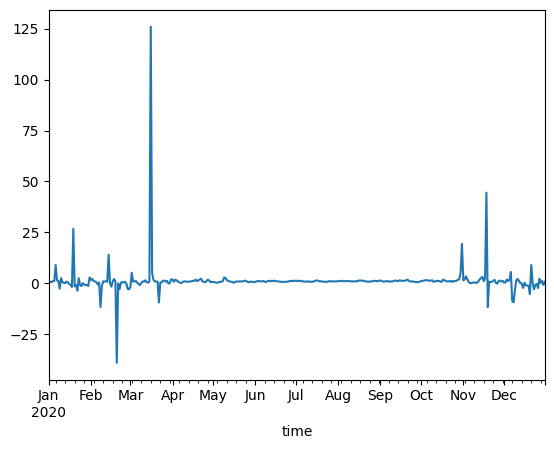

In [115]:
(df['tavg_prev_7']/df['tavg']).loc['2020'].plot()

<Axes: xlabel='time'>

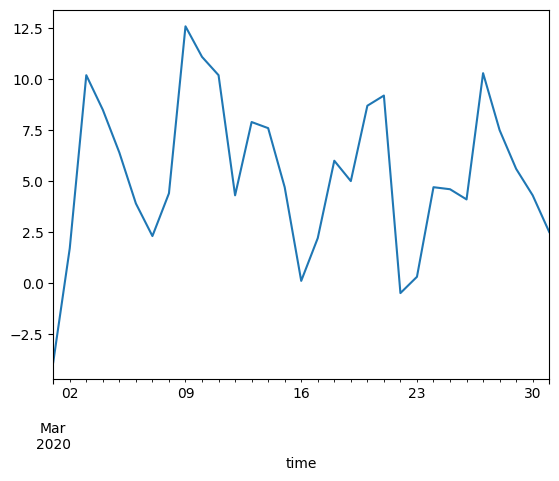

In [118]:
df.loc['2020-03']['tavg'].plot()